### Libraries

In [25]:
import json
import random
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer

In [ ]:
# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed) # Set the seed for the current GPU
    torch.cuda.manual_seed_all(seed) # Set the seed for all GPUs (if you are using multi-GPU).

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Set up Hugging Face cache directory
cache_dir = Path(r"C:/Users/User/Documents/devanasokan_fyp/huggingface_cache")
cache_dir.mkdir(parents=True, exist_ok=True)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased", cache_dir=str(cache_dir))
print(f"Tokenizer vocab size: {len(tokenizer)}")

Tokenizer vocab size: 30522


### Setup

In [4]:
# Load the datasets (Ratio of 70:15:15 for train, validation, and test sets)
train_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/train70.csv")
val_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/val15.csv")
test_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/test15.csv")

In [ ]:
# Load the datasets (Ratio of 80:10:10 for train, validation, and test sets)
train_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/train80.csv")
val_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/val10.csv")
test_df = pd.read_csv("C:/Users/User/Documents/devanasokan_fyp/modeldata/test10.csv")

In [5]:
print(train_df['label'].value_counts(normalize=True))
print(val_df['label'].value_counts(normalize=True))
print(test_df['label'].value_counts(normalize=True))

label
0    0.5
1    0.5
Name: proportion, dtype: float64
label
0    0.5
1    0.5
Name: proportion, dtype: float64
label
1    0.5
0    0.5
Name: proportion, dtype: float64


In [6]:
print("train:", train_df.shape, train_df["label"].value_counts().sort_index().to_dict())
print("val:", val_df.shape, val_df["label"].value_counts().sort_index().to_dict())
print("test:", test_df.shape, test_df["label"].value_counts().sort_index().to_dict())

train: (16014, 2) {0: 8007, 1: 8007}
val: (3432, 2) {0: 1716, 1: 1716}
test: (3432, 2) {0: 1716, 1: 1716}


In [7]:
MAX_LEN = 180


def tokenize(text: str) -> list[str]:
    return tokenizer.tokenize(text)


counter = Counter()
for text in train_df["verse"]:
    counter.update(tokenize(text))

vocab = tokenizer.get_vocab()

print(f"Vocabulary size: {len(vocab)}")
print("Most common tokens:", counter.most_common(10))

Token indices sequence length is longer than the specified maximum sequence length for this model (1221 > 512). Running this sequence through the model will result in indexing errors


Vocabulary size: 30522
Most common tokens: [(',', 188952), ('i', 48102), ('you', 35395), ('the', 27098), ('to', 21198), ('it', 17595), ('a', 17394), ('me', 15901), ('and', 15583), ('not', 13684)]


In [8]:
def numericalize(text: str) -> tuple[torch.Tensor, torch.Tensor]:
    token_ids = tokenizer.encode(
        text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LEN,
    )
    if not token_ids:
        token_ids = [tokenizer.unk_token_id]
    length = len(token_ids)
    if len(token_ids) < MAX_LEN:
        token_ids += [tokenizer.pad_token_id] * (MAX_LEN - len(token_ids))
    return torch.tensor(token_ids, dtype=torch.long), torch.tensor(length, dtype=torch.long)

sample_ids, sample_length = numericalize(train_df.iloc[0]["verse"] )
print("sample length:", sample_length.item())
print("sample ids:", sample_ids[:20].tolist())

sample length: 12
sample ids: [2054, 2057, 2113, 1010, 2073, 2017, 4618, 2175, 1010, 2373, 1010, 6289, 0, 0, 0, 0, 0, 0, 0, 0]


In [9]:
class LyricsDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.texts = frame["verse"].tolist()
        self.labels = frame["label"].astype(np.float32).tolist()

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int):
        input_ids, length = numericalize(self.texts[index])
        label = torch.tensor(self.labels[index], dtype=torch.float32)
        return input_ids, length, label

### Hyperparameter Tuning with Optuna

We'll search for the best hyperparameters using Optuna, which efficiently explores different combinations and focuses on promising regions. We'll tune:
- Learning rate (1e-4 to 1e-3)
- Embedding dimension (64, 128, 256)
- Hidden dimension (128, 256, 512)
- Number of layers (1, 2, 3)
- Dropout rate (0.1 to 0.5)
- Batch size (16, 32, 64)

In [ ]:
# Define the LSTM model
class RNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 128,
        hidden_dim: int = 128,
        num_layers: int = 2,
        bidirectional: bool = True,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=tokenizer.pad_token_id)
        self.rnn = nn.RNN(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity="tanh", # For RNN
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(output_dim, 1)

    def forward(self, input_ids: torch.Tensor, lengths: torch.Tensor) -> torch.Tensor:
        embedded = self.embedding(input_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, hidden = self.rnn(packed)
        if self.rnn.bidirectional:
            hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden = hidden[-1]
        logits = self.fc(self.dropout(hidden))
        return logits.squeeze(1)

In [ ]:
# Run one epoch of training or evaluation
def run_epoch(model, loader: DataLoader, criterion, optimizer=None, training: bool = True):
    model.train() if training else model.eval()

    total_loss = 0.0
    all_predictions = []
    all_probs = []
    all_targets = []

    for input_ids, lengths, labels in loader:
        input_ids = input_ids.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(training):
            logits = model(input_ids, lengths)
            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Get probability scores
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.detach().cpu().tolist())

        predictions = (probs >= 0.5).long()
        all_predictions.extend(predictions.detach().cpu().tolist())
        all_targets.extend(labels.detach().cpu().long().tolist())
        total_loss += loss.item() * input_ids.size(0)

    average_loss = total_loss / len(loader.dataset)
    accuracy = accuracy_score(all_targets, all_predictions)
    return average_loss, accuracy, all_targets, all_probs, all_predictions

In [ ]:
import optuna
from optuna.pruners import MedianPruner

# Define the objective function for hyperparameter tuning
def objective(trial: optuna.Trial):
    # Suggest hyperparameters
    learning_rate = trial.suggest_categorical("learning_rate", [1e-4, 5e-4, 1e-3])
    embedding_dim = trial.suggest_categorical("embedding_dim", [64, 128, 256])
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 256, 512])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_categorical("dropout", [0.1, 0.3, 0.5])
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Create data loaders with the suggested batch size
    train_loader = DataLoader(LyricsDataset(train_df), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(LyricsDataset(val_df), batch_size=batch_size, shuffle=False)

    # Initialize model with suggested hyperparameters
    model = RNNClassifier(
        vocab_size=len(tokenizer),
        embedding_dim=embedding_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    # Train for a few epochs
    num_epochs = 3
    best_val_loss = float("inf")

    for epoch in range(num_epochs):
        train_loss, train_acc, _, _, _ = run_epoch(model, train_loader, criterion, optimizer, training=True)
        val_loss, val_acc, _, _, _ = run_epoch(model, val_loader, criterion, training=False)

        print(f"  Trial {trial.number}, Epoch {epoch + 1}/{num_epochs}: val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss

        # Prune trial if validation loss is not improving
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return best_val_loss

In [ ]:
# For reproducibility, set a fixed seed for the TPE sampler
sampler = optuna.samplers.TPESampler(seed=42)

In [ ]:
# Create a study and run the hyperparameter search
study = optuna.create_study(
    direction="minimize",  # Minimize validation loss
    sampler=sampler, 
    pruner=MedianPruner(),
)

study.optimize(objective, n_trials=20, show_progress_bar=True)

[I 2026-07-30 16:23:47,084] A new study created in memory with name: no-name-13827b0f-a462-4380-8557-581dc7dce328
  0%|          | 0/20 [00:00<?, ?it/s]

  Trial 0, Epoch 1/3: val_loss=0.6759, val_acc=0.5801
  Trial 0, Epoch 2/3: val_loss=0.6787, val_acc=0.5758


Best trial: 0. Best value: 0.660122:   5%|▌         | 1/20 [02:33<48:45, 153.96s/it]

  Trial 0, Epoch 3/3: val_loss=0.6601, val_acc=0.6011
[I 2026-07-30 16:26:21,082] Trial 0 finished with value: 0.6601224212379723 and parameters: {'learning_rate': 0.001, 'embedding_dim': 256, 'hidden_dim': 256, 'num_layers': 3, 'dropout': 0.3, 'batch_size': 64}. Best is trial 0 with value: 0.6601224212379723.
  Trial 1, Epoch 1/3: val_loss=0.6654, val_acc=0.5985
  Trial 1, Epoch 2/3: val_loss=0.6988, val_acc=0.5452


Best trial: 1. Best value: 0.650394:  10%|█         | 2/20 [07:57<1:16:05, 253.64s/it]

...

  Trial 17, Epoch 3/3: val_loss=0.6672, val_acc=0.6340
[I 2026-07-30 16:57:24,369] Trial 17 finished with value: 0.6231901333048627 and parameters: {'learning_rate': 0.0001, 'embedding_dim': 128, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.5, 'batch_size': 32}. Best is trial 16 with value: 0.5903330955888841.


Best trial: 16. Best value: 0.590333:  95%|█████████▌| 19/20 [34:08<01:08, 68.21s/it]

  Trial 18, Epoch 1/3: val_loss=0.6806, val_acc=0.5720
[I 2026-07-30 16:57:55,259] Trial 18 pruned. 
  Trial 19, Epoch 1/3: val_loss=0.6499, val_acc=0.6195
  Trial 19, Epoch 2/3: val_loss=0.5866, val_acc=0.6847


Best trial: 19. Best value: 0.571691: 100%|██████████| 20/20 [35:50<00:00, 107.52s/it]

  Trial 19, Epoch 3/3: val_loss=0.5717, val_acc=0.7002
[I 2026-07-30 16:59:37,489] Trial 19 finished with value: 0.5716907816889125 and parameters: {'learning_rate': 0.0001, 'embedding_dim': 256, 'hidden_dim': 512, 'num_layers': 1, 'dropout': 0.5, 'batch_size': 64}. Best is trial 19 with value: 0.5716907816889125.


In [15]:
# Print best trial results
best_trial = study.best_trial

print(f"Best validation loss: {best_trial.value:.4f}")
print("Best hyperparameters:")
for key, value in best_trial.params.items():
    print(f"  {key}: {value}")

Best validation loss: 0.5717
Best hyperparameters:
  learning_rate: 0.0001
  embedding_dim: 256
  hidden_dim: 512
  num_layers: 1
  dropout: 0.5
  batch_size: 64


### Final Training with Best Hyperparameters

Train the final model using the best hyperparameters found by Optuna on the full train set, and evaluate on the test set.

In [17]:
# Extract best hyperparameters
best_params = best_trial.params
best_learning_rate = best_params["learning_rate"]
best_embedding_dim = best_params["embedding_dim"]
best_hidden_dim = best_params["hidden_dim"]
best_num_layers = best_params["num_layers"]
best_dropout = best_params["dropout"]
best_batch_size = best_params["batch_size"]

# Create data loaders with best batch size
train_loader = DataLoader(LyricsDataset(train_df), batch_size=best_batch_size, shuffle=True)
val_loader = DataLoader(LyricsDataset(val_df), batch_size=best_batch_size, shuffle=False)
test_loader = DataLoader(LyricsDataset(test_df), batch_size=best_batch_size, shuffle=False)

# Initialize final model with best hyperparameters
model = RNNClassifier(
    vocab_size=len(tokenizer),
    embedding_dim=best_embedding_dim,
    hidden_dim=best_hidden_dim,
    num_layers=best_num_layers,
    dropout=best_dropout,
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=best_learning_rate)

print("Final model architecture:")
print(model)

Final model architecture:
RNNClassifier(
  (embedding): Embedding(30522, 256, padding_idx=0)
  (rnn): RNN(256, 512, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=1024, out_features=1, bias=True)
)


In [ ]:
num_epochs = 10
best_val_loss = float("inf")
best_model_path = Path("rnn_lyrics_classifier.pt")
history = []

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc, train_targets, train_probs, train_predictions = run_epoch(model, train_loader, criterion, optimizer, training=True)
    val_loss, val_acc, val_targets, val_probs, val_predictions = run_epoch(model, val_loader, criterion, training=False)

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        }
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

history_df = pd.DataFrame(history)
history_df

Epoch 01 | train_loss=0.6818 train_acc=0.5622 | val_loss=0.6606 val_acc=0.5956
Epoch 02 | train_loss=0.6229 train_acc=0.6553 | val_loss=0.6231 val_acc=0.6608
Epoch 03 | train_loss=0.5806 train_acc=0.6983 | val_loss=0.6173 val_acc=0.6579
Epoch 04 | train_loss=0.5420 train_acc=0.7257 | val_loss=0.6094 val_acc=0.6705
Epoch 05 | train_loss=0.5105 train_acc=0.7524 | val_loss=0.5926 val_acc=0.6844
Epoch 06 | train_loss=0.4851 train_acc=0.7713 | val_loss=0.5622 val_acc=0.7305
Epoch 07 | train_loss=0.4482 train_acc=0.7905 | val_loss=0.5959 val_acc=0.6990
Epoch 08 | train_loss=0.4182 train_acc=0.8076 | val_loss=0.5766 val_acc=0.7302
Epoch 09 | train_loss=0.3799 train_acc=0.8320 | val_loss=0.5781 val_acc=0.7471
Epoch 10 | train_loss=0.3512 train_acc=0.8455 | val_loss=0.6145 val_acc=0.7273


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.681841,0.562196,0.660642,0.595571
1,2,0.622856,0.655302,0.623089,0.660839
2,3,0.580601,0.698326,0.617267,0.657925
3,4,0.542025,0.725678,0.609356,0.670455
4,5,0.510453,0.752404,0.592623,0.684441
5,6,0.485136,0.771263,0.562158,0.730478
6,7,0.448190,0.790496,0.595913,0.699009
7,8,0.418152,0.807606,0.576600,0.730186
8,9,0.379895,0.831960,0.578120,0.747086
9,10,0.351152,0.845510,0.614529,0.727273


### Model Evaluation

In [ ]:
# Load best checkpoint and evaluate on test
model.load_state_dict(torch.load(best_model_path, map_location=device))
test_loss, test_acc, test_targets, test_probs, test_predictions = run_epoch(model, test_loader, criterion, training=False)


Test loss: 0.5759
Test accuracy: 0.7281


#### Classification Report

In [24]:
report = classification_report(
    test_targets,
    test_predictions,
    output_dict=True
)

accuracy = report["accuracy"]
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"RNN CLASSIFICATION REPORT (TUNING):")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

RNN CLASSIFICATION REPORT (TUNING):
Accuracy: 0.7281468531468531
Precision: 0.7421150278293135
Recall: 0.6993006993006993
F1-score: 0.7200720072007201


#### ROC-AUC Curve

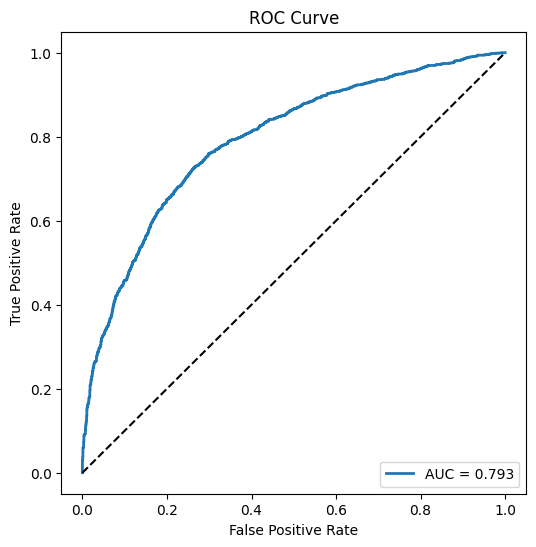

In [26]:
fpr, tpr, thresholds = roc_curve(test_targets, test_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.3f}",
    linewidth=2
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.show()

#### Precision-Recall Curve

PR-AUC: 0.7960060544170862


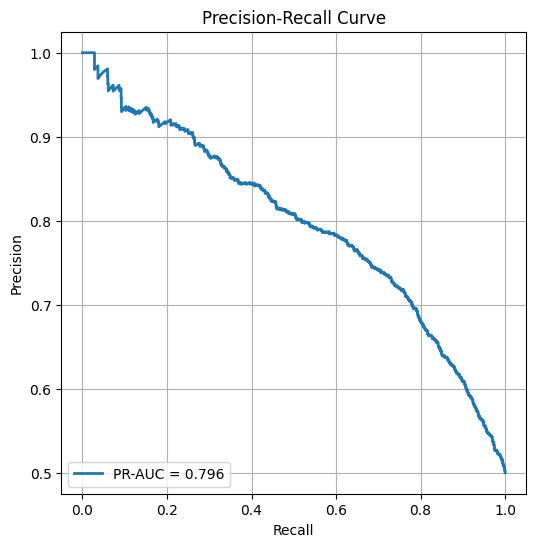

In [27]:
precision, recall, thresholds = precision_recall_curve(
    test_targets,
    test_probs
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

plt.figure(figsize=(6,6))

plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.3f}",
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend(loc="lower left")
plt.grid()

plt.show()

#### Confusion Matrix

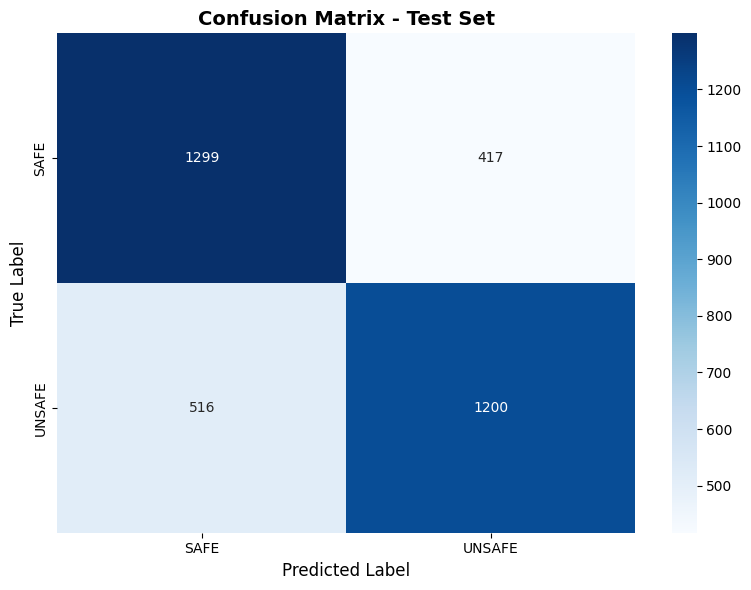

In [28]:
# Confusion matrix
cm = pd.crosstab(pd.Series(test_targets, name="Actual"), pd.Series(test_predictions, name="Predicted"))

# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # Show numbers in cells
    fmt='d',     # Format as integers
    cmap='Blues',  # Color palette
    cbar=True,   # Show color bar
    xticklabels=['SAFE', 'UNSAFE'],
    yticklabels=['SAFE', 'UNSAFE']
)
 
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

In [15]:
artifact_dir = Path("rnn_artifacts")
artifact_dir.mkdir(exist_ok=True)

model_path = artifact_dir / "lyrics_rnn.pt"
vocab_path = artifact_dir / "lyrics_vocab.json"
params_path = artifact_dir / "best_hyperparams.json"

torch.save(model.state_dict(), model_path)
with open(vocab_path, "w", encoding="utf-8") as vocab_file:
    json.dump(vocab, vocab_file, ensure_ascii=False, indent=2)
with open(params_path, "w", encoding="utf-8") as params_file:
    json.dump(best_params, params_file, indent=2)

print("Artifacts saved:")
print(f"  Model: {model_path}")
print(f"  Vocab: {vocab_path}")
print(f"  Best hyperparameters: {params_path}")

Artifacts saved:
  Model: rnn_artifacts\lyrics_rnn.pt
  Vocab: rnn_artifacts\lyrics_vocab.json
  Best hyperparameters: rnn_artifacts\best_hyperparams.json


In [20]:
def predict_text(text: str):
    model.eval()
    input_ids, length = numericalize(text)
    with torch.no_grad():
        logits = model(input_ids.unsqueeze(0).to(device), length.unsqueeze(0).to(device))
        probability = torch.sigmoid(logits).item()
        prediction = int(probability >= 0.5)
    return probability, prediction


sample_probability, sample_prediction = predict_text("you in the dark")
print({"probability": sample_probability, "prediction": sample_prediction})

{'probability': 0.11707007884979248, 'prediction': 0}
